# Lab Assignment: Data Quality & Data Cleaning for Data Warehouse

**สถานการณ์:** คุณเป็น Data Engineer ของร้านค้าออนไลน์ และได้รับไฟล์ `e_commerce_raw.csv` ที่ต้องเตรียมก่อนโหลดเข้าสู่ Data Warehouse  
**เป้าหมาย:** สำรวจปัญหาคุณภาพข้อมูล ออกแบบกฎการทำความสะอาด และส่งออกข้อมูลที่พร้อมใช้งาน

> ห้ามลบข้อมูลผิดปกติโดยไม่อธิบายเหตุผล ต้องพิจารณา Business Context โดยเฉพาะรายการโปรโมชัน


## ผลลัพธ์การเรียนรู้
1. ตรวจสอบข้อมูลด้วย `info()`, `isnull()`, `describe()` และ `duplicated()`
2. เชื่อมโยงปัญหากับ 6 มิติ: Accuracy, Completeness, Consistency, Uniqueness, Timeliness, Validity
3. จัดการ Missing Values และรูปแบบข้อมูลที่ไม่สอดคล้อง
4. ตรวจจับ Outlier ด้วย IQR และทำ Capping อย่างมีเหตุผล
5. สร้างไฟล์ Clean Data และรายงาน Data Quality ก่อน–หลัง


## 0) เตรียมระบบและอ่านข้อมูล

In [31]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = ROOT / 'New' / 'e_commerce_raw.csv'
OUTPUT_DIR = ROOT / 'outputs' / 'student_submission'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 50)
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()
print('Shape:', df.shape)
df.head()

Shape: (630, 16)


,Transaction_ID,Customer_ID,Customer_Name,Customer_Email,Gender,Province,Order_Date,Load_Timestamp,Product_Category,Quantity,Unit_Price,Discount_Rate,Transaction_Amount,Payment_Method,Order_Status,Is_Promotion
0,T000127,C0103,Tee Phromla,tee.phromla103@example.com,female,Phuket,2026-06-11,2026-06-11 05:00:00,Sports,3,110.26,0.05,314.24,PP,Cancelled,N
1,T000169,C0138,Mint Dechawat,mint.dechawat138@example.com,M,Khon Kaen,2026-01-24,2026-01-24 01:00:00,Home,3,138.08,0.05,393.53,PromptPay,Processing,N
2,T000003,C0071,Aom Sukjai,aom.sukjai71@example.com,m,Chanthaburi,05/29/2026,2026-05-29 05:00:00,Home,4,263.93,0.00,1055.72,COD,Cancelled,N
3,T000336,C0152,Tee Dechawat,tee.dechawat152@example.com,male,Chanthaburi,02/01/2026,2026-02-01 18:00:00,Food,6,116.53,0.10,629.26,Transfer,Returned,N
4,T000093,C0090,Mook Sukjai,mook.sukjai90@example.com,M,Chanthaburi,2026-04-18,2026-04-18 13:00:00,Electronics,5,358.35,0.00,1791.75,promptpay,Processing,N


## 1) Data Profiling

ให้แสดงผลต่อไปนี้และเขียนข้อสังเกตใต้เซลล์
- โครงสร้างและชนิดข้อมูล
- จำนวน Missing Values รายคอลัมน์
- สถิติเชิงพรรณนาของข้อมูลตัวเลข
- จำนวนแถวซ้ำทั้งแถว
- จำนวนค่าที่แตกต่างในคอลัมน์สำคัญ


In [32]:
# TODO 1: Data Profiling
# ตัวอย่างคำสั่งที่ควรใช้: df.info(), df.isnull().sum(), df.describe(), df.duplicated().sum()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630 entries, 0 to 629
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction_ID      630 non-null    object 
 1   Customer_ID         630 non-null    object 
 2   Customer_Name       630 non-null    object 
 3   Customer_Email      580 non-null    object 
 4   Gender              630 non-null    object 
 5   Province            618 non-null    object 
 6   Order_Date          630 non-null    object 
 7   Load_Timestamp      630 non-null    object 
 8   Product_Category    630 non-null    object 
 9   Quantity            630 non-null    int64  
 10  Unit_Price          630 non-null    float64
 11  Discount_Rate       630 non-null    float64
 12  Transaction_Amount  630 non-null    float64
 13  Payment_Method      630 non-null    object 
 14  Order_Status        630 non-null    object 
 15  Is_Promotion        630 non-null    object 
dtypes: float

,0
Transaction_ID,0
Customer_ID,0
Customer_Name,0
Customer_Email,50
Gender,0
Province,12
Order_Date,0
Load_Timestamp,0
Product_Category,0
Quantity,0


In [ ]:
df.describe()


,Quantity,Unit_Price,Discount_Rate,Transaction_Amount
count,630.000000,630.000000,630.000000,630.000000
mean,3.660317,227.080365,0.061746,6092.293000
std,4.184784,126.984729,0.066935,66925.290163
min,-3.000000,37.360000,0.000000,-500.000000
25%,2.000000,137.095000,0.000000,316.190000
50%,3.000000,198.935000,0.050000,579.600000
75%,5.000000,298.615000,0.100000,1037.892500
max,99.000000,779.430000,0.200000,999999.000000


In [ ]:
df.duplicated().sum()

np.int64(18)

### คำถาม 1
ระบุปัญหาที่พบอย่างน้อย **5 ปัญหา** และจับคู่กับมิติ Data Quality อย่างน้อย **3 มิติ**

| ปัญหาที่พบ | คอลัมน์ | มิติ Data Quality | หลักฐาน/จำนวนแถว |
|---|---|---|---|
| | | | |


1. ข้อมูล Customer_Email มีค่า Missing (Null)
2. ข้อมูล Province มีค่า Missing (Null)
3. รูปแบบอีเมลไม่ถูกต้อง เช่น ไม่มี @ หรือโดเมน
4. จังหวัดสะกดไม่เหมือนกัน เช่น Bangkok, BKK, กรุงเทพฯ, กรุงเทพมหานคร
5. พบข้อมูลลูกค้าซ้ำ (Duplicate Customer)

## 2) Completeness: จัดการ Missing Values

In [ ]:
# =========================
# TODO 2.1: ตรวจสอบ Customer_Email และ Province ที่หายไป
# =========================

print("Missing Values")
print(df[["Customer_Email", "Province"]].isna().sum())

# แสดงแถวที่มีข้อมูลหาย
display(df[df["Customer_Email"].isna() | df["Province"].isna()])


# =========================
# TODO 2.2: เติม Customer_Email โดยไม่ทำให้แถว Fact หาย
# แนวคิดสำหรับ DW: Unknown Member + Flag
# =========================

# สร้าง Flag ก่อนเติมค่า
df["Customer_Email_Missing_Flag"] = df["Customer_Email"].isna()

# เติม Placeholder
df["Customer_Email"] = df["Customer_Email"].fillna("unknown@dw.local")


# =========================
# TODO 2.3: เติม Province ที่หายเป็น 'Unknown' พร้อม Flag
# =========================

# สร้าง Flag ก่อนเติมค่า
df["Province_Missing_Flag"] = df["Province"].isna()

# เติมค่า Unknown
df["Province"] = df["Province"].fillna("Unknown")


# =========================
# ตรวจสอบผลลัพธ์
# =========================

print("\nหลังจัดการ Missing Values")
print(df[["Customer_Email", "Province"]].isna().sum())

display(
    df[
        [
            "Customer_Email",
            "Customer_Email_Missing_Flag",
            "Province",
            "Province_Missing_Flag",
        ]
    ]
)

Missing Values
Customer_Email    0
Province          0
dtype: int64


,Transaction_ID,Customer_ID,Customer_Name,Customer_Email,Gender,Province,Order_Date,Load_Timestamp,Product_Category,Quantity,Unit_Price,Discount_Rate,Transaction_Amount,Payment_Method,Order_Status,Is_Promotion,Customer_Email_Missing_Flag,Province_Missing_Flag



หลังจัดการ Missing Values
Customer_Email    0
Province          0
dtype: int64


,Customer_Email,Customer_Email_Missing_Flag,Province,Province_Missing_Flag
0,tee.phromla103@example.com,False,Phuket,False
1,mint.dechawat138@example.com,False,Khon Kaen,False
2,aom.sukjai71@example.com,False,Chanthaburi,False
3,tee.dechawat152@example.com,False,Chanthaburi,False
4,mook.sukjai90@example.com,False,Chanthaburi,False
...,...,...,...,...
625,boss.dechawat48@example.com,False,Rayong,False
626,unknown@dw.local,False,Khon Kaen,False
627,aom.sukjai71@example.com,False,Chanthaburi,False
628,beam.srisawat83@example.com,False,Chiang Mai,False


### คำถาม 2
อธิบายว่าเหตุใดการใช้ `dropna()` กับ `Customer_Email` อาจทำให้ยอดขายรวมใน Data Warehouse ผิดเพี้ยน และเหตุใดการเติมค่าเฉลี่ยจึงไม่เหมาะกับข้อมูลประเภทอีเมล


การใช้ dropna() กับ Customer_Email: ทำให้ข้อมูลธุรกรรมบางรายการถูกลบ ส่งผลให้ยอดขายรวมใน Data Warehouse คลาดเคลื่อน
การเติมค่าเฉลี่ยให้ Customer_Email: ไม่เหมาะเพราะอีเมลเป็นข้อมูลข้อความ ไม่สามารถคำนวณค่าเฉลี่ยได้

## 3) Consistency: จัดรูปแบบข้อมูลให้เป็นมาตรฐาน

In [ ]:
# =========================
# TODO 3.1: Standardize Gender ให้เหลือ M, F, Unknown
# =========================
gender_map = {
    "M": "M", "Male": "M", "male": "M", "m": "M",
    "F": "F", "Female": "F", "female": "F", "f": "F"
}
df["Gender"] = (
    df["Gender"]
    .astype(str)
    .str.strip()
    .map(gender_map)
    .fillna("Unknown")
)
# =========================
# TODO 3.2: Standardize Payment_Method
# =========================
payment_map = {
    "Credit Card": "Credit Card",
    "credit card": "Credit Card",
    "CreditCard": "Credit Card",
    "CC": "Credit Card",
    "PromptPay": "PromptPay",
    "Prompt Pay": "PromptPay",
    "promptpay": "PromptPay",
    "Cash on Delivery": "Cash on Delivery",
    "COD": "Cash on Delivery",
    "Cash": "Cash on Delivery",
    "Bank Transfer": "Bank Transfer",
    "Transfer": "Bank Transfer",
    "Bank": "Bank Transfer"
}
df["Payment_Method"] = (
    df["Payment_Method"]
    .astype(str)
    .str.strip()
    .map(payment_map)
    .fillna("Unknown")
)
# =========================
# TODO 3.3: แปลง Order_Date เป็น YYYY-MM-DD
# ใช้ Load_Timestamp ช่วยตัดสินใจ
# =========================
df["Load_Timestamp"] = pd.to_datetime(df["Load_Timestamp"], errors="coerce")
date_dayfirst = pd.to_datetime(
    df["Order_Date"],
    errors="coerce",
    dayfirst=True
)
date_monthfirst = pd.to_datetime(
    df["Order_Date"],
    errors="coerce",
    dayfirst=False
)
df["Order_Date_Fallback_Flag"] = False
df["Order_Date"] = date_dayfirst
mask = df["Order_Date"].isna() & date_monthfirst.notna()
df.loc[mask, "Order_Date"] = date_monthfirst[mask]
df.loc[mask, "Order_Date_Fallback_Flag"] = True
mask = df["Order_Date"].isna() & df["Load_Timestamp"].notna()
df.loc[mask, "Order_Date"] = df.loc[mask, "Load_Timestamp"]
df.loc[mask, "Order_Date_Fallback_Flag"] = True
df["Order_Date"] = df["Order_Date"].dt.strftime("%Y-%m-%d")
display(df[[
    "Gender",
    "Payment_Method",
    "Order_Date",
    "Order_Date_Fallback_Flag"
]].head())



,Gender,Payment_Method,Order_Date,Order_Date_Fallback_Flag
0,F,Unknown,2026-11-06,False
1,M,PromptPay,2026-01-24,True
2,M,Cash on Delivery,2026-05-29,True
3,M,Bank Transfer,2026-02-01,True
4,M,PromptPay,2026-04-18,True


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


### คำถาม 3
ยกตัวอย่าง 1 วันที่สามารถตีความได้ทั้ง DD/MM/YYYY และ MM/DD/YYYY แล้วอธิบายว่าคุณใช้หลักฐานใดช่วยตัดสิน


# วันที่ 03/04/2025
ตีความได้ 2 แบบ:
DD/MM/YYYY → 3 เมษายน 2025
MM/DD/YYYY → 4 มีนาคม 2025
ใช้คอลัมน์ Load_Timestamp เป็นข้อมูลประกอบ โดยเลือกวันที่ที่สอดคล้องกับช่วงเวลาที่ข้อมูลถูกนำเข้าระบบมากที่สุด

## 4) Uniqueness: ข้อมูลซ้ำและความซ้ำซ้อนเชิงความหมาย

In [ ]:
# =========================
# TODO 4.1: นับและลบ Exact Duplicates โดยเก็บแถวแรก
# =========================
duplicate_count = df.duplicated().sum()
print("Exact Duplicates:", duplicate_count)
df = df.drop_duplicates(keep="first")
print("จำนวนข้อมูลหลังลบ Duplicate:", len(df))
# =========================
# TODO 4.2 (Bonus):
# ตรวจหาลูกค้าที่ Customer_Email เดียวกัน
# แต่ Customer_Name เขียนต่างกัน
# =========================
near_duplicate = (
    df.groupby("Customer_Email")["Customer_Name"]
      .nunique()
      .reset_index()
)
near_duplicate = near_duplicate[near_duplicate["Customer_Name"] > 1]

print("Near Duplicate Customers")
display(near_duplicate)
# แสดงรายละเอียด
display(
    df[df["Customer_Email"].isin(near_duplicate["Customer_Email"])]
    .sort_values("Customer_Email")
)

Exact Duplicates: 18
จำนวนข้อมูลหลังลบ Duplicate: 612
Near Duplicate Customers


,Customer_Email,Customer_Name
147,ploy.saelim47@example.com,2
167,unknown@dw.local,40


,Transaction_ID,Customer_ID,Customer_Name,Customer_Email,Gender,Province,Order_Date,Load_Timestamp,Product_Category,Quantity,Unit_Price,Discount_Rate,Transaction_Amount,Payment_Method,Order_Status,Is_Promotion,Customer_Email_Missing_Flag,Province_Missing_Flag,Order_Date_Fallback_Flag
319,T000219,C0047,Ploy Saelim,ploy.saelim47@example.com,F,Khon Kaen,2026-07-02,2026-02-07 04:00:00,Electronics,2,133.02,0.20,212.83,Cash on Delivery,Returned,N,False,False,False
388,T000378,C0047,Ploy Saelim,ploy.saelim47@example.com,F,Khon Kaen,2026-05-18,2026-05-18 17:00:00,Home,2,149.97,0.05,284.94,Bank Transfer,Processing,N,False,False,True
96,T000088,C0047,Ploy Saelim,ploy.saelim47@example.com,F,Khon Kaen,2026-04-11,2026-04-11 17:00:00,Electronics,3,383.05,0.00,1149.15,Bank Transfer,Returned,N,False,False,True
97,T900011,C0047,Ploy Saelim,ploy.saelim47@example.com,F,Khon Kaen,2026-05-18,2026-05-18 17:00:00,Home,2,149.97,0.05,284.94,Bank Transfer,Processing,N,False,False,True
236,T900010,C0047,Ploy Saelim,ploy.saelim47@example.com,F,Khon Kaen,2026-05-05,2026-05-05 01:00:00,Food,4,319.22,0.00,1276.88,Credit Card,Completed,N,False,False,False
122,T000413,C0047,Ploy Saelim,ploy.saelim47@example.com,Unknown,Khon Kaen,2026-04-11,2026-04-11 13:00:00,Food,1,439.01,0.10,395.11,Unknown,Returned,N,False,False,True
208,T000195,C0047,Ploy Saelim,ploy.saelim47@example.com,F,Khon Kaen,2026-05-05,2026-05-05 01:00:00,Food,4,319.22,0.00,1276.88,Credit Card,Completed,N,False,False,False
381,T000312,C0012,Mint Pattanakul,unknown@dw.local,M,Chiang Mai,2026-03-25,2026-03-25 09:00:00,Home,1,373.85,0.10,336.47,Bank Transfer,Completed,N,False,False,True
386,T000151,C0003,Mint Thongdee,unknown@dw.local,M,Phuket,2026-05-13,2026-05-13 04:00:00,Electronics,5,221.56,0.15,941.63,Credit Card,Completed,N,False,False,True
389,T000081,C0005,Ploy Chaiyo,unknown@dw.local,F,Bangkok,2026-10-06,2026-06-11 09:00:00,Food,3,95.64,0.10,258.23,Credit Card,Processing,N,False,False,False


## 5) Accuracy และ Validity: ตรวจสอบกฎธุรกิจ

In [ ]:
# =========================
# TODO 5.1: แปลง Quantity, Unit_Price,
# Discount_Rate และ Transaction_Amount เป็นตัวเลข
# =========================
numeric_cols = [
    "Quantity",
    "Unit_Price",
    "Discount_Rate",
    "Transaction_Amount"
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
# =========================
# TODO 5.2: ตรวจ Quantity ต้องอยู่ในช่วง 1-20
# =========================
df["Quantity_Validity_Flag"] = df["Quantity"].between(1, 20)

print("จำนวน Quantity ที่ไม่ถูกต้อง:",
      (~df["Quantity_Validity_Flag"]).sum())
# =========================
# TODO 5.3: คำนวณ Expected_Amount
# และสร้าง Accuracy_Flag
# =========================

df["Expected_Amount"] = (
    df["Quantity"]
    * df["Unit_Price"]
    * (1 - df["Discount_Rate"])
)
df["Expected_Amount"] = df["Expected_Amount"].round(2)
df["Accuracy_Flag"] = (
    (df["Transaction_Amount"] - df["Expected_Amount"]).abs() <= 1
)
print("จำนวนรายการที่ยอดเงินไม่ถูกต้อง:",
      (~df["Accuracy_Flag"]).sum())
# =========================
# TODO 5.4: Standardize Order_Status
# และตรวจ Validity
# =========================
status_map = {
    "Completed": "Completed",
    "Complete": "Completed",
    "completed": "Completed",
    "Pending": "Pending",
    "pending": "Pending",
    "Cancelled": "Cancelled",
    "Canceled": "Cancelled",
    "cancelled": "Cancelled",
    "Returned": "Returned",
    "returned": "Returned"
}
df["Order_Status"] = (
    df["Order_Status"]
      .astype(str)
      .str.strip()
      .map(status_map)
      .fillna("Unknown")
)
valid_status = [
    "Completed",
    "Pending",
    "Cancelled",
    "Returned"
]
df["Order_Status_Validity_Flag"] = df["Order_Status"].isin(valid_status)

print("จำนวน Order_Status ที่ไม่ถูกต้อง:",
      (~df["Order_Status_Validity_Flag"]).sum())
display(df[[
    "Quantity",
    "Unit_Price",
    "Discount_Rate",
    "Transaction_Amount",
    "Expected_Amount",
    "Accuracy_Flag",
    "Order_Status",
    "Order_Status_Validity_Flag"
]].head())



จำนวน Quantity ที่ไม่ถูกต้อง: 3
จำนวนรายการที่ยอดเงินไม่ถูกต้อง: 64
จำนวน Order_Status ที่ไม่ถูกต้อง: 175


/tmp/ipykernel_2265/2232254002.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = pd.to_numeric(df[col], errors="coerce")
/tmp/ipykernel_2265/2232254002.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Quantity_Validity_Flag"] = df["Quantity"].between(1, 20)
/tmp/ipykernel_2265/2232254002.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://

,Quantity,Unit_Price,Discount_Rate,Transaction_Amount,Expected_Amount,Accuracy_Flag,Order_Status,Order_Status_Validity_Flag
0,3,110.26,0.05,314.24,314.24,True,Cancelled,True
1,3,138.08,0.05,393.53,393.53,True,Unknown,False
2,4,263.93,0.00,1055.72,1055.72,True,Cancelled,True
3,6,116.53,0.10,629.26,629.26,True,Returned,True
4,5,358.35,0.00,1791.75,1791.75,True,Unknown,False


### คำถาม 4
รายการที่ `Transaction_Amount` ไม่ตรงกับสูตรควรแก้ไขทุกแถวหรือไม่? ให้อธิบายผลของ `Is_Promotion` ต่อการตัดสินใจ


ไม่ควรแก้ไขทุกแถวทันที

หาก Is_Promotion = True ความแตกต่างของ Transaction_Amount อาจเกิดจากการใช้โปรโมชั่น เช่น คูปอง ส่วนลดพิเศษ หรือโปรซื้อ 1 แถม 1 จึงควรตรวจสอบก่อน ไม่ควรแก้ไขอัตโนมัติ

แต่หาก Is_Promotion = False และยอดเงินยังไม่ตรงกับสูตร ก็มีโอกาสเป็นความผิดพลาดของข้อมูล (Data Error) และควรตรวจสอบหรือแก้ไขต่อไป

Q1 = 310.80
Q3 = 1023.48
IQR = 712.68
Lower Bound = -758.22
Upper Bound = 2092.50
จำนวน Outlier = 0


/tmp/ipykernel_2265/3465021010.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Transaction_Amount_Before"] = df["Transaction_Amount"]
/tmp/ipykernel_2265/3465021010.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Outlier_Flag"] = False


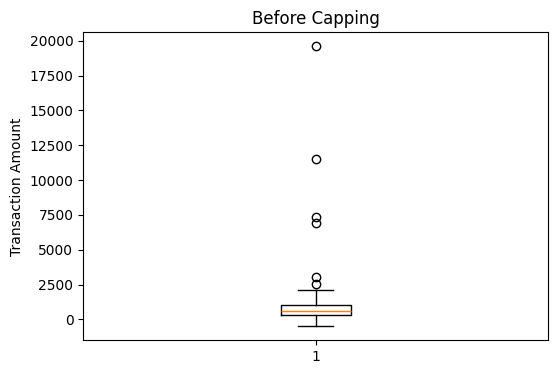

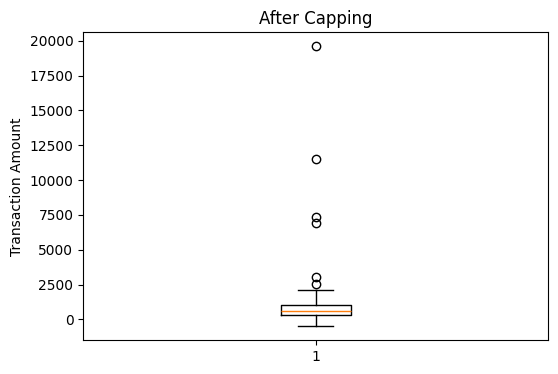

In [ ]:
# =========================
# TODO 6.1: คำนวณ IQR จากรายการที่ไม่ใช่โปรโมชัน
# =========================
# เก็บข้อมูลก่อน Capping
df["Transaction_Amount_Before"] = df["Transaction_Amount"]
# เลือกเฉพาะรายการที่ไม่ใช่โปรโมชัน
non_promo = df[df["Is_Promotion"] != "Y"]
Q1 = non_promo["Transaction_Amount"].quantile(0.25)
Q3 = non_promo["Transaction_Amount"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"Q1 = {Q1:.2f}")
print(f"Q3 = {Q3:.2f}")
print(f"IQR = {IQR:.2f}")
print(f"Lower Bound = {lower_bound:.2f}")
print(f"Upper Bound = {upper_bound:.2f}")

# =========================
# TODO 6.2: สร้าง Outlier Flag
# =========================
df["Outlier_Flag"] = False

mask = (
    (df["Is_Promotion"] != "Y") &
    (
        (df["Transaction_Amount"] < lower_bound) |
        (df["Transaction_Amount"] > upper_bound)
    )
)
df.loc[mask, "Outlier_Flag"] = True
print("จำนวน Outlier =", df["Outlier_Flag"].sum())
# =========================
# TODO 6.3: Capping ด้วย clip()
# เฉพาะรายการที่ไม่ใช่โปรโมชัน
# =========================

df.loc[df["Is_Promotion"] != "Y", "Transaction_Amount"] = (
    df.loc[df["Is_Promotion"] != "Y", "Transaction_Amount"]
      .clip(lower=lower_bound, upper=upper_bound)
)
# =========================
# TODO 6.4: Boxplot ก่อนและหลัง Capping
# =========================
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.boxplot(df["Transaction_Amount_Before"].dropna())
plt.title("Before Capping")
plt.ylabel("Transaction Amount")
plt.show()
plt.figure(figsize=(6,4))
plt.boxplot(df["Transaction_Amount"].dropna())
plt.title("After Capping")
plt.ylabel("Transaction Amount")
plt.show()


### คำถาม 5
เพราะเหตุใดข้อมูลที่อยู่นอก IQR Bound จึงไม่จำเป็นต้องเป็นข้อมูลผิดเสมอ? ยกตัวอย่างจาก Dataset นี้


ข้อมูลที่อยู่นอก IQR Bound ไม่จำเป็นต้องเป็นข้อมูลผิดเพราะอาจเป็นค่าที่เกิดขึ้นจริงแต่มีค่าสูงหรือต่ำกว่าปกติ

## 7) Timeliness: ความทันเวลาในการโหลดข้อมูล

In [ ]:
# =========================
# TODO 7: คำนวณ Load_Delay_Hours
# =========================

# แปลงเป็น datetime (เผื่อยังไม่ได้แปลง)
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")
df["Load_Timestamp"] = pd.to_datetime(df["Load_Timestamp"], errors="coerce")

# คำนวณเวลาที่ใช้ในการโหลดข้อมูล (ชั่วโมง)
df["Load_Delay_Hours"] = (
    df["Load_Timestamp"] - df["Order_Date"]
).dt.total_seconds() / 3600

# กำหนด Late เมื่อมากกว่า 24 ชั่วโมง
df["Late_Flag"] = df["Load_Delay_Hours"] > 24

# สรุปจำนวนและร้อยละ
late_count = df["Late_Flag"].sum()
total_count = len(df)
late_percent = (late_count / total_count) * 100

print(f"Late Records : {late_count}")
print(f"Late Percent : {late_percent:.2f}%")

# แสดงตัวอย่าง
display(df[[
    "Order_Date",
    "Load_Timestamp",
    "Load_Delay_Hours",
    "Late_Flag"
]].head())



Late Records : 39
Late Percent : 6.37%


/tmp/ipykernel_2265/2261824343.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")
/tmp/ipykernel_2265/2261824343.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Load_Timestamp"] = pd.to_datetime(df["Load_Timestamp"], errors="coerce")
/tmp/ipykernel_2265/2261824343.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cavea

,Order_Date,Load_Timestamp,Load_Delay_Hours,Late_Flag
0,2026-11-06,2026-06-11 05:00:00,-3547.0,False
1,2026-01-24,2026-01-24 01:00:00,1.0,False
2,2026-05-29,2026-05-29 05:00:00,5.0,False
3,2026-02-01,2026-02-01 18:00:00,18.0,False
4,2026-04-18,2026-04-18 13:00:00,13.0,False


## 8) Data Quality Report และ Export

In [ ]:
# =========================
# TODO 8.1: สรุปตัวชี้วัดก่อนและหลัง Cleaning
# =========================
report = pd.DataFrame({
    "Metric": [
        "Rows",
        "Missing Email",
        "Exact Duplicates",
        "Invalid Dates",
        "Mismatched Amounts",
        "Outliers Capped",
        "Late Loads",
        "Invalid Statuses"
    ],
    "Value": [
        len(df),
        df["Customer_Email"].eq("unknown@dw.local").sum(),
        duplicate_count,
        df["Order_Date"].isna().sum(),
        (~df["Accuracy_Flag"]).sum(),
        df["Outlier_Flag"].sum(),
        df["Late_Flag"].sum(),
        (~df["Order_Status_Validity_Flag"]).sum()
    ]
})

display(report)
# =========================
# TODO 8.2: Export
# =========================
df.to_csv(
    OUTPUT_DIR / "e_commerce_clean.csv",
    index=False,
    encoding="utf-8-sig"
)

report.to_csv(
    OUTPUT_DIR / "data_quality_report.csv",
    index=False,
    encoding="utf-8-sig"
)
print("Export completed!")
print("Saved:")
print("- e_commerce_clean.csv")
print("- data_quality_report.csv")


,Metric,Value
0,Rows,612
1,Missing Email,48
2,Exact Duplicates,18
3,Invalid Dates,0
4,Mismatched Amounts,64
5,Outliers Capped,0
6,Late Loads,39
7,Invalid Statuses,175


Export completed!
Saved:
- e_commerce_clean.csv
- data_quality_report.csv


## 9) Reflection
ตอบเป็นย่อหน้าสั้น ๆ
1. ขั้นตอนใดมีความเสี่ยงทำให้ข้อมูลจริงสูญหายมากที่สุด?
2. กฎใดควรนำไปทำ Automation ใน Data Pipeline?
3. หากใช้ Great Expectations คุณจะสร้าง Expectation ใดอย่างน้อย 3 ข้อ?


1.ขั้นตอนที่มีความเสี่ยงทำให้ข้อมูลจริงสูญหายมากที่สุด คือการใช้ dropna() และ drop_duplicates() เพราะอาจลบข้อมูลธุรกรรมที่ถูกต้องออกจาก Data Warehouse
2.กฎที่ควรนำไปทำ Automation ใน Data Pipeline ได้แก่ การตรวจ Missing Value, การ Standardize
3.(1) Customer_Email ต้องไม่เป็นค่าว่าง (2) Quantity ต้องอยู่ในช่วง 1-20 และ (3) Order_Status ต้องเป็นหนึ่งใน Completed, Pending, Cancelled หรือ Returned เพื่อช่วยตรวจสอบคุณภาพข้อมูลอัตโนมัติก่อนนำเข้า Data Warehouse

## Checklist ก่อนส่ง
- [ ] Notebook รันจากบนลงล่างได้โดยไม่ Error
- [ ] มีคำตอบคำถามทั้ง 5 ข้อและ Reflection
- [ ] ส่ง `e_commerce_clean.csv`
- [ ] ส่ง `data_quality_report.csv`
- [ ] ไม่ลบรายการโปรโมชันเพียงเพราะเป็น Outlier


In [33]:
df.to_csv(
    OUTPUT_DIR / "e_commerce_clean.csv",
    index=False,
    encoding="utf-8-sig"
)

In [ ]:
df.to_csv(
    OUTPUT_DIR / "e_commerce_clean.csv",
    index=False,
    encoding="utf-8-sig"
)

report.to_csv(
    OUTPUT_DIR / "data_quality_report.csv",
    index=False,
    encoding="utf-8-sig"
)

In [37]:
from google.colab import files

files.download(OUTPUT_DIR / "e_commerce_clean.csv")
files.download(OUTPUT_DIR / "data_quality_report.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>